Show what happens with simple patients and increasing varaibility

Analyzing placebo response for STD=0.1, n=22133
Median Percent Change (PC) in placebo arm: 0.015%


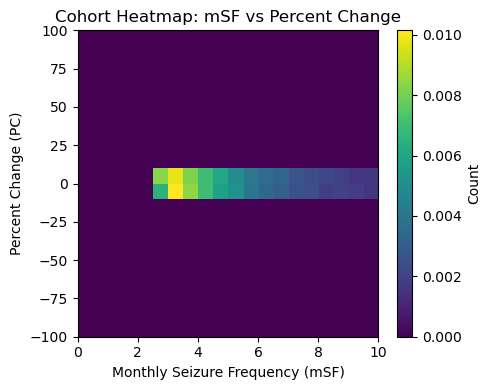

Analyzing placebo response for STD=0.5, n=22579
Median Percent Change (PC) in placebo arm: 0.438%


<Figure size 640x480 with 0 Axes>

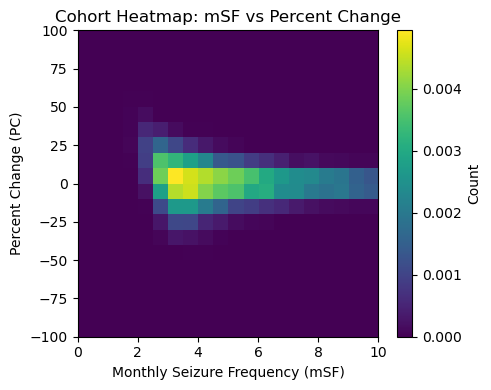

Analyzing placebo response for STD=1, n=22756
Median Percent Change (PC) in placebo arm: 1.589%


<Figure size 640x480 with 0 Axes>

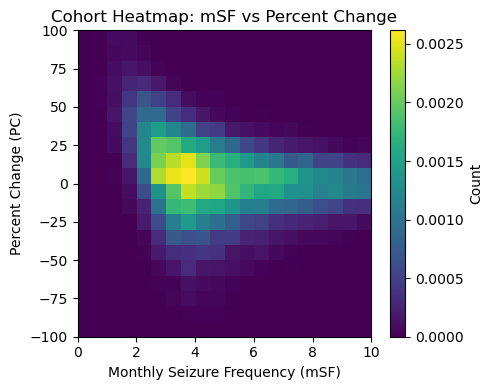

Analyzing placebo response for STD=1.5, n=23634
Median Percent Change (PC) in placebo arm: 3.626%


<Figure size 640x480 with 0 Axes>

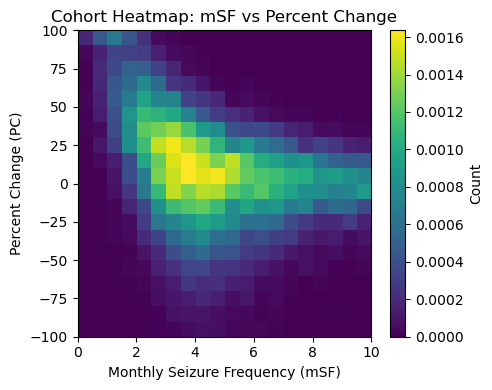

Analyzing placebo response for STD=2, n=24515
Median Percent Change (PC) in placebo arm: 6.496%


<Figure size 640x480 with 0 Axes>

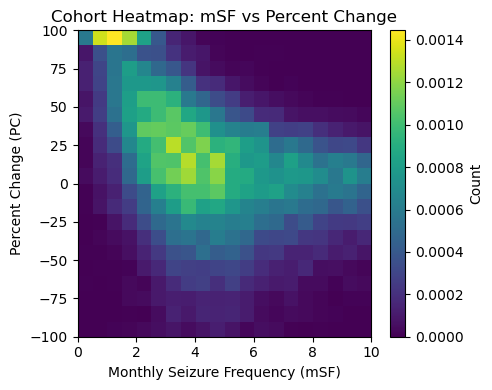

Analyzing placebo response for STD=2.5, n=25153
Median Percent Change (PC) in placebo arm: 10.305%


<Figure size 640x480 with 0 Axes>

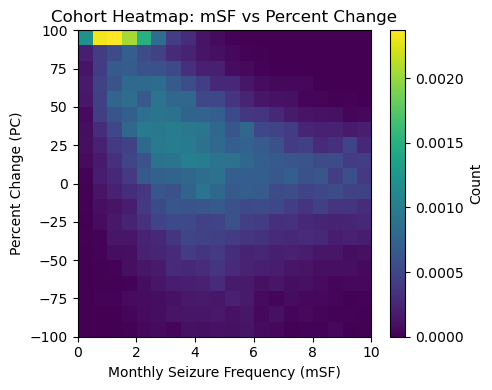

Analyzing placebo response for STD=3, n=25626
Median Percent Change (PC) in placebo arm: 12.822%


<Figure size 640x480 with 0 Axes>

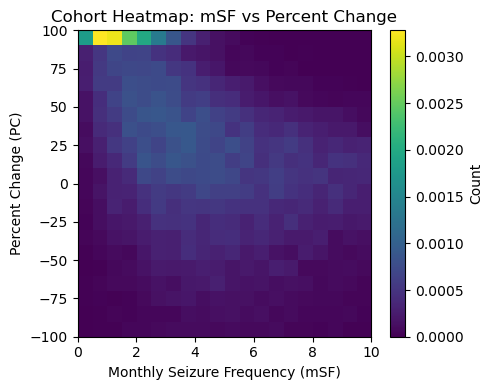

<Figure size 640x480 with 0 Axes>

In [ ]:
from rtm_tools import analyze_placebo_response,generate_simplified_cohort

MIN = 4

for STD in [.1,0.5,1,1.5,2,2.5,3]:
    cohort = generate_simplified_cohort(num_patients=100000, STD = STD, eligibility_min=MIN)
    print(f"Analyzing placebo response for STD={STD}, n={len(cohort)}")
    analyze_placebo_response(cohort, eligibility_min=MIN)



then add in complex patients, same question

In [2]:
from rtm_tools import generate_complex_cohort,analyze_placebo_response
import rtm_constants as CONST
NUM_PTS = 200000
FAR = 0.0 
figOut = False

with open(CONST.OUTPUT_FILENAME, 'w') as f:
    f.write('Sensitivity,FAR,BaselineTF,MIN,fracCohort,MPCmean,MPCsem,RR50,MPC_mSFlo,fracMPClo,MPC_mSFhi,fracMPChi,MPC_Blo,fracBlo,MPC_Bhi,fracBhi\n')
for FAR in [0,1/30,1/7,1]:
    for sens in [0.25,0.5,0.6,0.7,0.8,0.85,0.9,0.95,0.99,1.0]:
        for baselineTF in [True,False]:
            for MIN in [2,3,4,5,6]:
                cohort = generate_complex_cohort(num_patients=NUM_PTS,  eligibility_min=MIN, 
                    use_baseline=baselineTF, sensitivity=sens, FAR=FAR)
                print(f'{sens},{FAR},{baselineTF},{MIN},{len(cohort)/NUM_PTS:5.3f},',end='')
                with open(CONST.OUTPUT_FILENAME, 'a') as f:
                    f.write(f'{sens},{FAR},{baselineTF},{MIN},{len(cohort)/NUM_PTS:5.3f},')
                analyze_placebo_response(cohort, eligibility_min=MIN, figOut = False)

0.25,0,True,2,0.096,20.000,  nan,0.000,20.000,1.000,  nan,0.000,20.000,1.000


/Users/dgoldenh/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


0.25,0,True,3,0.064,22.222,  nan,0.000,22.222,1.000,  nan,0.000,22.222,1.000
0.25,0,True,4,0.048,27.273,  nan,0.000,27.273,1.000,  nan,0.000,27.273,1.000
0.25,0,True,5,0.037,30.435,  nan,0.000,30.435,1.000,  nan,0.000,30.435,1.000
0.25,0,True,6,0.029,33.333,  nan,0.000,33.333,1.000,  nan,0.000,33.333,1.000
0.25,0,False,2,0.095,-1.192,  nan,0.000,-1.192,1.000,-100.000,0.232,12.546,0.768
0.25,0,False,3,0.064,-3.704,  nan,0.000,-3.704,1.000,-113.333,0.283,16.667,0.717
0.25,0,False,4,0.049,-4.762,  nan,0.000,-4.762,1.000,-100.000,0.342,20.000,0.658
0.25,0,False,5,0.037,-4.348,  nan,0.000,-4.348,1.000,-80.952,0.384,22.807,0.616
0.25,0,False,6,0.029,-5.556,  nan,0.000,-5.556,1.000,-73.333,0.418,21.739,0.582
0.5,0,True,2,0.197,13.333,75.556,0.003,12.821,0.997,  nan,0.000,13.333,1.000
0.5,0,True,3,0.138,14.286,66.667,0.002,14.286,0.998,  nan,0.000,14.286,1.000
0.5,0,True,4,0.102,17.647,66.667,0.002,17.460,0.998,  nan,0.000,17.647,1.000
0.5,0,True,5,0.080,20.000,66.667,0.001,20.000,0.999,  nan,

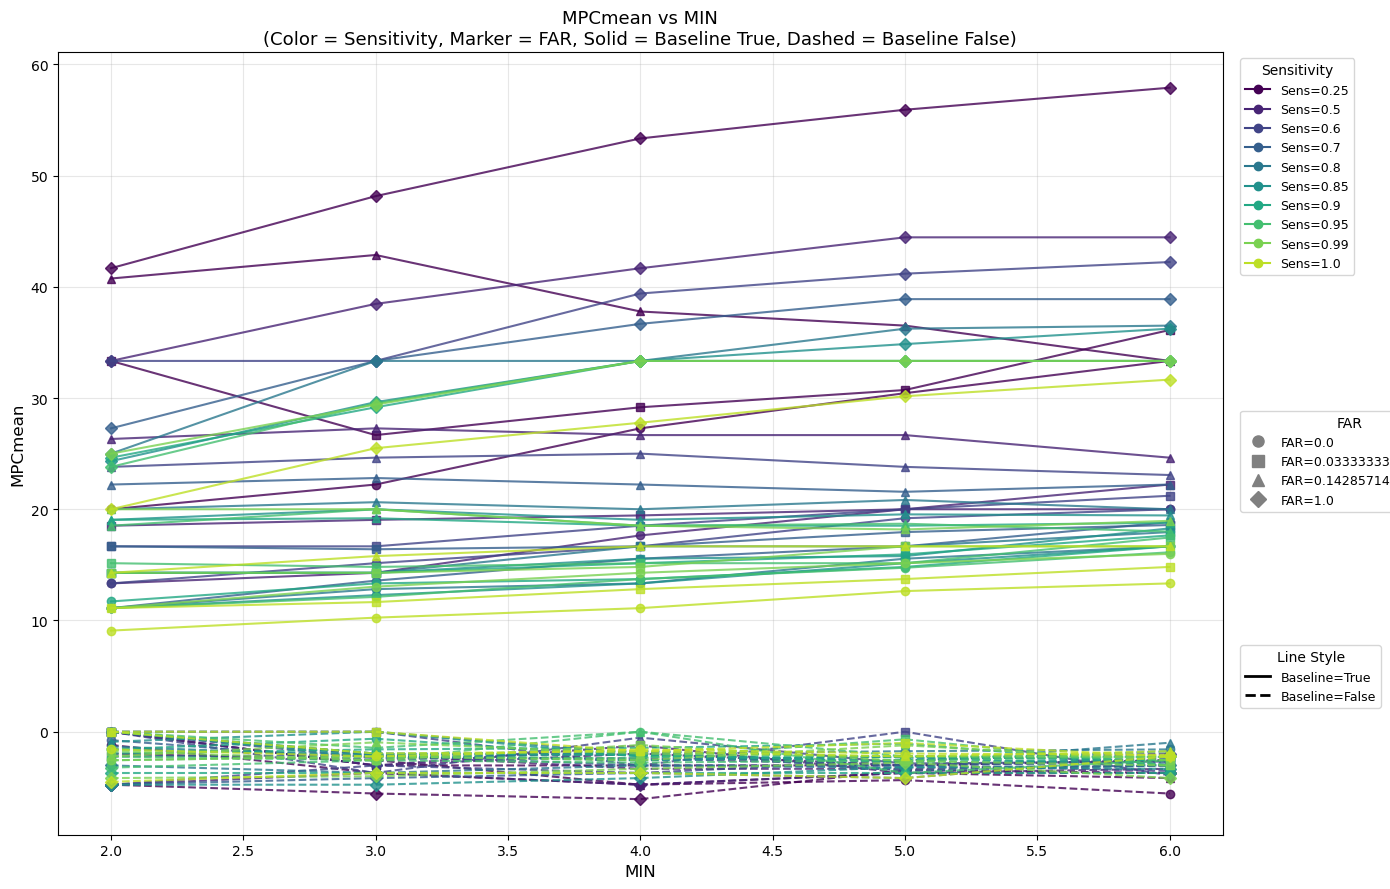

In [ ]:
from plotting_tools import plot_all_combos_of_meanMPC_vs_MIN

plot_all_combos_of_meanMPC_vs_MIN()

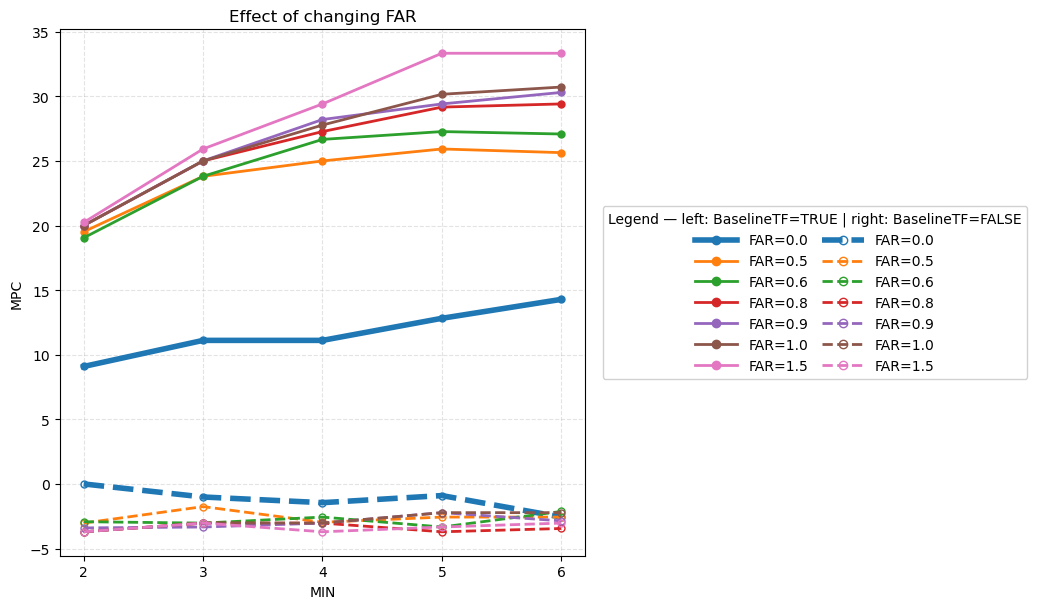

In [ ]:
from plotting_tools import make_FAR_plot
make_FAR_plot()


In [1]:
from rtm_tools import test1_sensitivity_par,test2_FAR_par
import pandas as pd
x123 = pd.DataFrame()
num_patients = 1000000
for baseline in [True,False]:
    print(f"Running test1_sensitivity_par with baseline={baseline}")
    x1 = test1_sensitivity_par(use_baseline=baseline,num_patients=num_patients)
    print(x1)
    print(f"Running test2_FAR_par with baseline={baseline}")
    x2 = test2_FAR_par(use_baseline=baseline, correct_FAR=True,num_patients=num_patients    )
    print(x2)
    print(f"Running test3_FAR_par with baseline={baseline}")
    x3 = test2_FAR_par(use_baseline=baseline, correct_FAR=False,num_patients=num_patients)
    print(x3)
    x123 = pd.concat([x123,x1,x2,x3],ignore_index=True)
    
x123.to_csv('rtm_test123_results.csv',index=False)


Running test1_sensitivity_par with baseline=True
   sensitivity  FAR  use_baseline  correct_FAR  fraction_eligible  frac_RTM  \
0          0.1  0.0          True         True           0.016173  0.732455   
1          0.2  0.0          True         True           0.047447  0.637364   
2          0.3  0.0          True         True           0.081320  0.584899   
3          0.4  0.0          True         True           0.118577  0.547248   
4          0.5  0.0          True         True           0.156912  0.504111   
5          0.6  0.0          True         True           0.196334  0.462406   
6          0.7  0.0          True         True           0.233403  0.431100   
7          0.8  0.0          True         True           0.268045  0.406872   
8          0.9  0.0          True         True           0.300654  0.386128   
9          1.0  0.0          True         True           0.330603  0.365453   

         MPC  ekligibility_min  eligibility_monthly_min  \
0  47.619048          

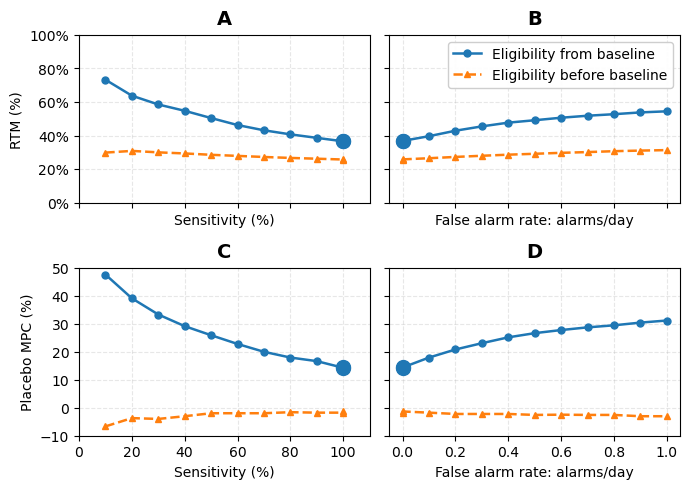

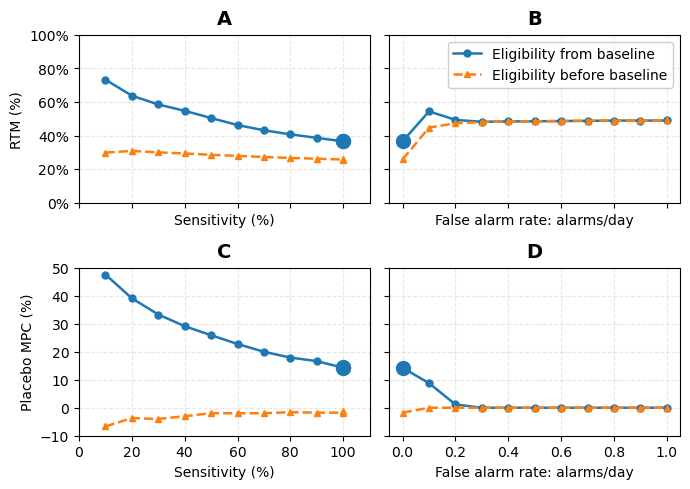

In [2]:
from plotting_tools import draw_sens_and_far_vs_RTM_v2
import matplotlib.pyplot as plt
draw_sens_and_far_vs_RTM_v2(correct_far=True)
plt.savefig('sensitivity_and_FAR_vs_RTM.png',dpi=300)
draw_sens_and_far_vs_RTM_v2(correct_far=False)



In [6]:
from rtm_tools import test3_N_for_efficacy_par
import numpy as np
import pandas as pd

def  run_one_time(SENS,FAR,correct_FAR,use_baseline,drug_effect,Nlist,sz_min,min_monthly,sz_longest_free,efficacy_fn,ntrials):

    R,closest_N_for_90,closest_N_for_90R,frac_eligible = test3_N_for_efficacy_par(sensitivity=SENS,FAR=FAR, num_trials=ntrials,
        sz_min=sz_min,sz_monthly_min=min_monthly, sz_longest_free=sz_longest_free,
        num_patients=max(Nlist),drug_effect=drug_effect, Nlist=Nlist, use_baseline=use_baseline,correct_FAR=correct_FAR)
    MPC_pcb = np.mean(R['MPC_pcb_maxN'])
    MPC_drug = np.mean(R['MPC_drug_maxN'])
    print(f'UseBaseline={use_baseline}, Drug Effect={drug_effect}, MPC_pcb={MPC_pcb}, MPC_drug={MPC_drug}')
    print(f'Sensivity = {SENS}, FAR = {FAR}, CorrectingFAR={correct_FAR} N={closest_N_for_90}, N_R={closest_N_for_90R}')
    print(f'Fraction Eligible={frac_eligible} mSF_mean={np.mean(R["mSF_median"])} rtm_fraction={np.mean(R["rtm_fraction"])}')
    with open(efficacy_fn,'a') as f:
        f.write(f'{SENS},{FAR},{correct_FAR},{use_baseline},{drug_effect},{closest_N_for_90},{closest_N_for_90R},{frac_eligible},{np.mean(R["mSF_median"])},{MPC_pcb},{MPC_drug},{np.mean(R["rtm_fraction"])}\n')

ntrials = 100000
efficacy_fn = f'rtm_efficacy_results_{ntrials}.csv'
FAR = 0.0
drug_effect = 0.31
sz_longest_free = 25
sz_min = 4
min_monthly = 3
use_baseline = True

In [7]:

#Nlist = np.arange(40,121,4).tolist()
#Nlist = [70,80,90,100,110,120,130,140,150,200,210,220,230,240,250,260,270,280,290,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000,1050,1100]
#Nlist = np.arange(40,100,4).tolist()

with open(efficacy_fn,'w') as f:
    f.write('Sensitivity,FAR,CorrectFAR,useBaselineTF,drugEffect,N_for_90M,N_for_90R,FractionEligible,Mean_mSF_median,MPC_pcb,MPC_drug,rtm_fraction\n')

if 1:
    # akready tried this at 10000 trials
    Nlist = np.arange(70,950,2).tolist()
    SENS = 1
    FAR = 0.0
    drug_effect = 0.2
    correct_FAR = True
    powerTarget = 0.9
    for use_baseline in [False,True]:
        run_one_time(SENS,FAR,correct_FAR,use_baseline,drug_effect,Nlist,sz_min,
                    min_monthly,sz_longest_free,efficacy_fn,ntrials)
    
    drug_effect = 0.31
    Nlist = np.arange(40,400,2).tolist()
    SENS = 1
    FAR = 0.0
    use_baseline = True
    correct_FAR = True
    for SENS in [1,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1]:
        run_one_time(SENS,FAR,correct_FAR,use_baseline,drug_effect,Nlist,sz_min,
                    min_monthly,sz_longest_free,efficacy_fn,ntrials)
    
SENS = 1
drug_effect = 0.31
use_baseline = True
correct_FAR = True
Nlist = np.arange(40,450,2).tolist()
for FAR in [0.0, 1/30,1/7,1]:
    for correct_FAR in [True,False]:
        run_one_time(SENS,FAR,correct_FAR,use_baseline,drug_effect,Nlist,sz_min,
                    min_monthly,sz_longest_free,efficacy_fn,ntrials)


UseBaseline=False, Drug Effect=0.2, MPC_pcb=-1.7314963987765113, MPC_drug=18.606270514562162
Sensivity = 1, FAR = 0.0, CorrectingFAR=True N=206, N_R=626
Fraction Eligible=0.3305789292832741 mSF_mean=8.621921808463549 rtm_fraction=0.2573007067510549
UseBaseline=True, Drug Effect=0.2, MPC_pcb=14.436588285407256, MPC_drug=31.544272971683814
Sensivity = 1, FAR = 0.0, CorrectingFAR=True N=160, N_R=402
Fraction Eligible=0.33053522383008865 mSF_mean=8.621575850602188 rtm_fraction=0.36715066455696194
UseBaseline=True, Drug Effect=0.31, MPC_pcb=14.37877099302037, MPC_drug=40.925884365685725
Sensivity = 1, FAR = 0.0, CorrectingFAR=True N=58, N_R=132
Fraction Eligible=0.33085641360986856 mSF_mean=8.625098216570402 rtm_fraction=0.36719010050251266
UseBaseline=True, Drug Effect=0.31, MPC_pcb=15.878916708886525, MPC_drug=41.97047812896499
Sensivity = 0.9, FAR = 0.0, CorrectingFAR=True N=60, N_R=132
Fraction Eligible=0.3013106863500797 mSF_mean=9.038585288549552 rtm_fraction=0.3842159296482413
UseBas

In [1]:
from rtm_tools import test4_N_for_Type1error_par
import numpy as np
sensitivity = 1
sz_min = 4
sz_monthly_min = 3
sz_longest_free = 25
num_trials = 1000
Nlist = [50,80,100,200,300,500,800,1000]
num_patients = max(Nlist)
use_baseline = True
correct_FAR = True
print('FAR,CorrectFAR,N,mpc,rr50')
for FAR in [0,1/30,1/7,1]:
    for correct_FAR in [True,False]:
        R, success, successR = test4_N_for_Type1error_par(sensitivity,FAR,sz_min,sz_monthly_min,
                        sz_longest_free,num_trials,num_patients,
                        Nlist,use_baseline,correct_FAR)
        for i, N in enumerate(Nlist):
            print(f'{FAR},{correct_FAR},',end='')
            print(f'{N}, {success[i]}, {successR[i]}')

FAR,CorrectFAR,N,mpc,rr50
0,True,50, 0.063, 0.035
0,True,80, 0.082, 0.047
0,True,100, 0.083, 0.06
0,True,200, 0.096, 0.061
0,True,300, 0.111, 0.101
0,True,500, 0.162, 0.155
0,True,800, 0.214, 0.227
0,True,1000, 0.258, 0.264
0,False,50, 0.061, 0.034
0,False,80, 0.075, 0.049
0,False,100, 0.078, 0.067
0,False,200, 0.091, 0.067
0,False,300, 0.108, 0.102
0,False,500, 0.165, 0.139
0,False,800, 0.212, 0.19
0,False,1000, 0.265, 0.243
0.03333333333333333,True,50, 0.064, 0.035
0.03333333333333333,True,80, 0.071, 0.052
0.03333333333333333,True,100, 0.076, 0.054
0.03333333333333333,True,200, 0.094, 0.085
0.03333333333333333,True,300, 0.121, 0.098
0.03333333333333333,True,500, 0.151, 0.141
0.03333333333333333,True,800, 0.215, 0.195
0.03333333333333333,True,1000, 0.256, 0.236
0.03333333333333333,False,50, 0.066, 0.028
0.03333333333333333,False,80, 0.074, 0.05
0.03333333333333333,False,100, 0.069, 0.045
0.03333333333333333,False,200, 0.095, 0.058
0.03333333333333333,False,300, 0.127, 0.126
0.03333333

In [ ]:
from rtm_tools_v2 import test1,test2,test3
import pandas as pd

NUM_TRIALS = 100000
NUM_PTS = 250
test1(numTrials=NUM_TRIALS, numPatients=NUM_PTS, recruitmentMonths=36, baselineMonths=2, testMonths=3,
        sensitivity=1.0, FAR=0.0, eligibility_rate=4, min_monthly_rate=3, max_szfree_days=25,
        treatment_effect=0.2, correct_FAR=False, fn='v2_test_baselineTF.csv')

NUM_PTS = 100
test2(numTrials=NUM_TRIALS, numPatients=NUM_PTS, recruitmentMonths=36, baselineMonths=2, testMonths=3,
        FAR=0.0, eligibility_rate=4, min_monthly_rate=3, max_szfree_days=25,
        treatment_effect=0.31, correct_FAR=False, use_baselineTF=True, fn='v2_test_sensitivity.csv')

test3(numTrials=NUM_TRIALS, numPatients=NUM_PTS, recruitmentMonths=36, baselineMonths=2, testMonths=3,
        sensitivity=1.0, eligibility_rate=4, min_monthly_rate=3,
        max_szfree_days=25, treatment_effect=0.31, use_baselineTF=True,
        fn='v2_test_FAR.csv')

Simulating Trials:   0%|          | 0/5000 [00:00<?, ?it/s]

   numPatients  recruitmentMonths  baselineMonths  testMonths  sensitivity  \
0          250                 36               2           3          1.0   

   FAR  eligibility_rate  min_monthly_rate  max_szfree_days  treatment_effect  \
0  0.0                 4                 3               25               0.2   

   ...  mean_diffMPC  mean_drugRR50  mean_placeboRR50  mean_diffRR50  \
0  ...     14.991694       39.11824           28.2632       10.85504   

   successRR50  successMPC  mean_mSF  mean_eligibility_rate  \
0         40.7       76.04  5.347659               41.07435   

   mean_failed_baseline_rate  mean_fraction_RTM  
0                        0.0           0.418315  

[1 rows x 24 columns]


Simulating Trials:   0%|          | 0/5000 [00:00<?, ?it/s]

   numPatients  recruitmentMonths  baselineMonths  testMonths  sensitivity  \
0          250                 36               2           3          1.0   

   FAR  eligibility_rate  min_monthly_rate  max_szfree_days  treatment_effect  \
0  0.0                 4                 3               25               0.2   

   ...  mean_diffMPC  mean_drugRR50  mean_placeboRR50  mean_diffRR50  \
0  ...     19.954576       21.99168            14.624        7.36768   

   successRR50  successMPC  mean_mSF  mean_eligibility_rate  \
0        26.54        71.7  5.430963              40.713261   

   mean_failed_baseline_rate  mean_fraction_RTM  
0                   1.623722           0.226621  

[1 rows x 24 columns]
